In [3]:
import h5py
import numpy as np
from pathlib import Path

# Point to your data folder
data_dir = Path("10-fish-0066")

# Find all H5 tracking files
h5_files = sorted(data_dir.glob("*_fov.h5"))
print(f"Found {len(h5_files)} files. Starting network generation...\n")

for h5_path in h5_files:
    base_name = h5_path.stem.replace('_fov', '')
    
    with h5py.File(h5_path, 'r') as f:
        x_t = f['fields/x'][:].T
        y_t = f['fields/y'][:].T
        hx_t = f['fields/heading_x'][:].T
        hy_t = f['fields/heading_y'][:].T
        bl_t = f['fields/body_length'][:].T  
        
    
    # Distances
    dx = x_t[:, :, np.newaxis] - x_t[:, np.newaxis, :]
    dy = y_t[:, :, np.newaxis] - y_t[:, np.newaxis, :]
    distances = np.sqrt(dx**2 + dy**2)
    
    # Dynamic Threshold Mask: D_ij <= 0.5 * Body Length of Fish i
    # We add an axis to body length so it broadcasts against the distance matrix
    bl_i = bl_t[:, :, np.newaxis] 
    proximity_mask = (distances <= (1.0 * bl_i)).astype(float)
    
    # Directed Mask (Field of View)
    dot_product = (hx_t[:, :, np.newaxis] * dx) + (hy_t[:, :, np.newaxis] * dy)
    dist_safe = np.where(distances == 0, np.inf, distances)
    cos_theta = dot_product / dist_safe
    fov_mask = (cos_theta > -0.5).astype(float) # ~240 degree visual field
    
    # Weights (Exponential decay scaled by the fish's own body length)
    bl_safe = np.where(bl_i == 0, np.inf, bl_i)
    weights = np.exp(-distances / bl_safe)
    
    # Combine to create the final Directed & Weighted Network
    network = weights * proximity_mask * fov_mask
    
    # Remove self-connections (Diagonal = 0)
    np.einsum('ijj->ij', network)[...] = 0
    
    # Save the data as a NumPy array for later use
    save_path = data_dir / f"{base_name}_network.npy"
    np.save(save_path, network)
    
    print(f"Saved: {save_path.name} | Shape: {network.shape}")

print("\nAll networks successfully generated and saved!")

Found 7 files. Starting network generation...

Saved: 0066_000_network.npy | Shape: (3596, 10, 10)
Saved: 0066_001_network.npy | Shape: (3595, 10, 10)
Saved: 0066_002_network.npy | Shape: (3596, 10, 10)
Saved: 0066_003_network.npy | Shape: (3595, 10, 10)
Saved: 0066_004_network.npy | Shape: (3595, 10, 10)
Saved: 0066_005_network.npy | Shape: (3596, 10, 10)
Saved: 0066_006_network.npy | Shape: (3005, 10, 10)

All networks successfully generated and saved!


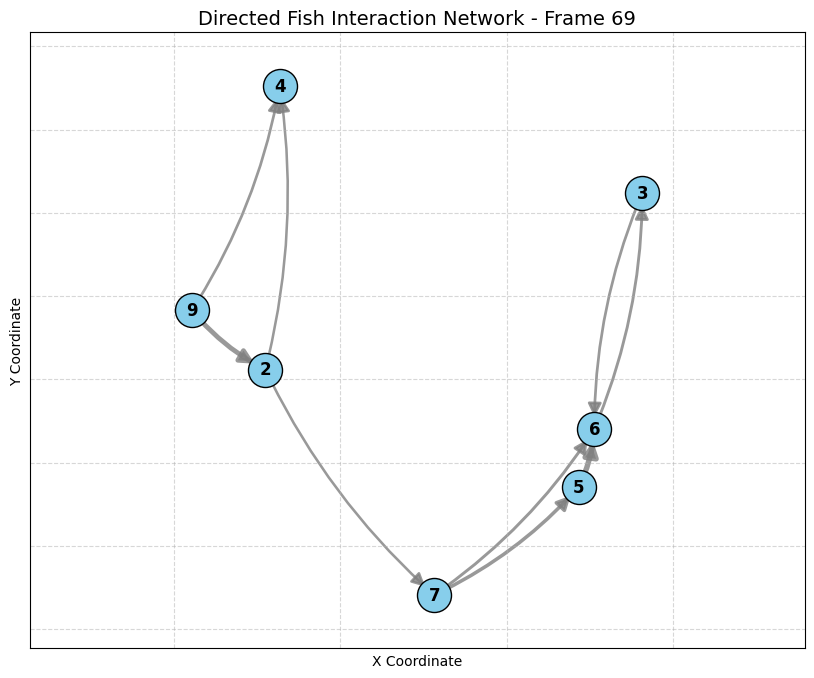

In [ ]:
import numpy as np
import h5py
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

base_name = "0066_000" ## Change the h5 file to visualize different data
data_dir = Path("10-fish-0066")

h5_path = data_dir / f"{base_name}_fov.h5"
npy_path = data_dir / f"{base_name}_network.npy"

with h5py.File(h5_path, 'r') as f:
    x_coords = f['fields/x'][:]
    y_coords = f['fields/y'][:]

dynamic_network = np.load(npy_path)

frame_idx = 68  # Change this to look at different moments in time

G = nx.DiGraph() # Define directed graph

# Extract the 10x10 adjacency matrix for our chosen frame
adj_matrix = dynamic_network[frame_idx]
    
# Add edges based on the matrix
for i in range(10):
    for j in range(10):
        weight = adj_matrix[i, j]
        if weight > 0: # If there is a connection (passed threshold + FOV)
            G.add_edge(i, j, weight=weight)

# Create a dictionary of real-world positions for the nodes
pos = {i: (x_coords[i, frame_idx], y_coords[i, frame_idx]) for i in range(10)}

# plotting the graph 
plt.figure(figsize=(10, 8))

# Draw the nodes (Fish)
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='skyblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_weight='bold')

edges = G.edges(data=True)
line_widths = [data['weight'] * 5 for u, v, data in edges]

nx.draw_networkx_edges(
    G, pos,
    edgelist=edges,
    width=line_widths,
    arrowsize=20, 
    arrowstyle='-|>',   
    connectionstyle='arc3, rad=0.1', # Curves the lines so A->B and B->A don't overlap!
    edge_color='gray',
    alpha=0.8
)

plt.title(f"Directed Fish Interaction Network - Frame {frame_idx}", fontsize=14)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

# Keep the aspect ratio 1:1 so the tank doesn't look stretched
plt.axis('equal') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

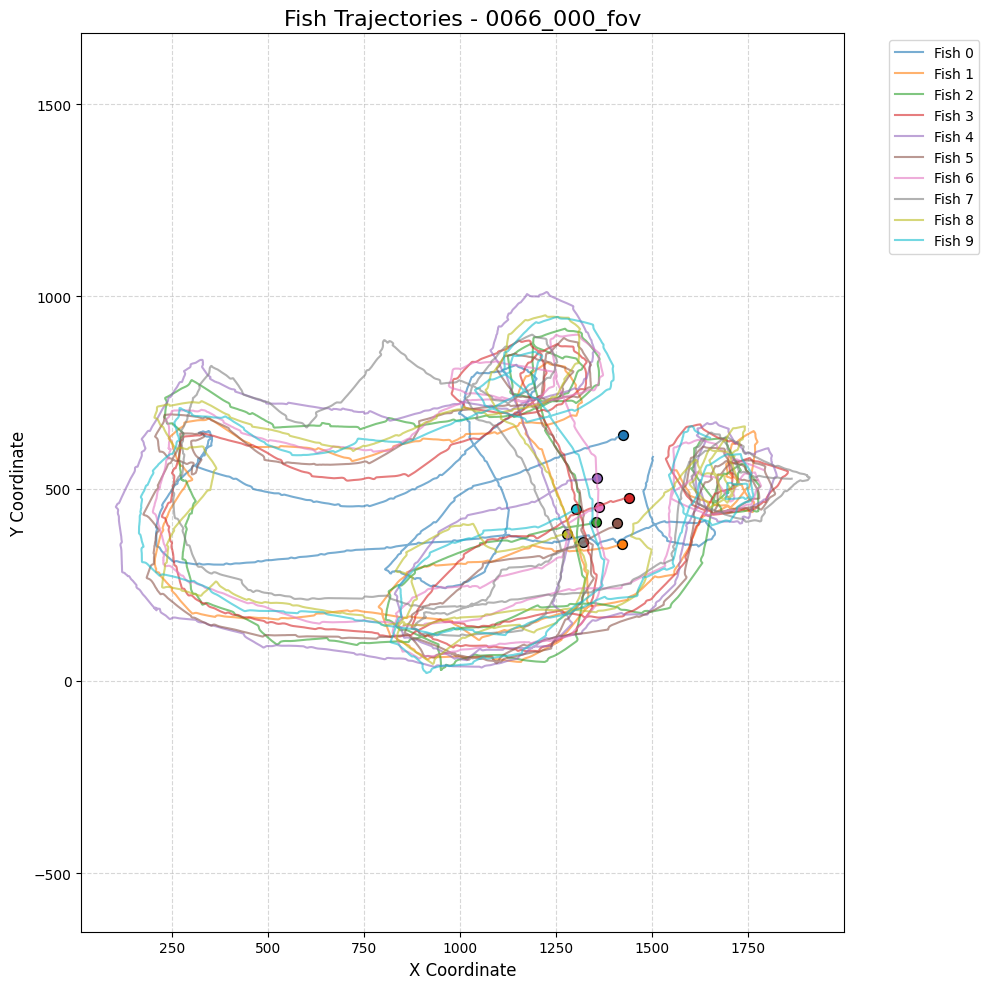

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path("10-fish-0066")
h5_files = sorted(data_dir.glob("*_fov.h5"))

if len(h5_files) > 0:
    h5_path = h5_files[0]
    
    with h5py.File(h5_path, 'r') as f:
        x_t = f['fields/x'][:].T
        y_t = f['fields/y'][:].T
        
    num_frames, num_fish = x_t.shape
    
    plt.figure(figsize=(10, 10))
    
    for fish_idx in range(num_fish):
        plt.plot(x_t[:, fish_idx], y_t[:, fish_idx], alpha=0.6, label=f'Fish {fish_idx}')
        
        plt.scatter(x_t[0, fish_idx], y_t[0, fish_idx], marker='o', s=50, edgecolors='black')
        
    plt.title(f"Fish Trajectories - {h5_path.stem}", fontsize=16)
    plt.xlabel("X Coordinate", fontsize=12)
    plt.ylabel("Y Coordinate", fontsize=12)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.axis('equal') 
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No H5 files found.")

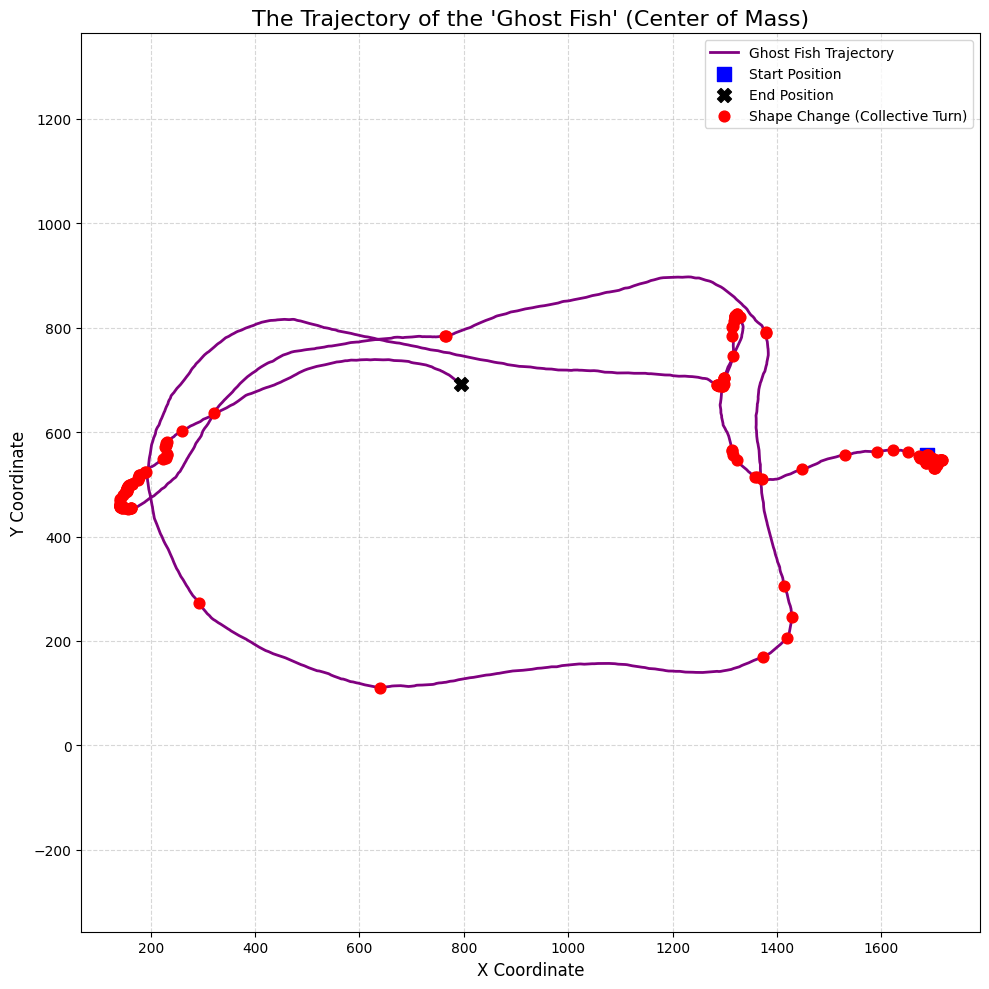

In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

h5_path = "10-fish-0066/0066_001_fov.h5"  # Update path if necessary
with h5py.File(h5_path, 'r') as f:
    x_t = f['fields/x'][:].T
    y_t = f['fields/y'][:].T


x_ghost = np.mean(x_t, axis=1)
y_ghost = np.mean(y_t, axis=1)

vx = np.diff(x_t, axis=0)
vy = np.diff(y_t, axis=0)
vx_group = np.mean(vx, axis=1)
vy_group = np.mean(vy, axis=1)

group_headings = np.arctan2(vy_group, vx_group)
group_turns = np.abs(np.diff(group_headings))
group_turns = np.minimum(group_turns, 2 * np.pi - group_turns)

collective_turn_threshold = 0.3 # Radians
collective_turn_frames = np.where(group_turns > collective_turn_threshold)[0]

plt.figure(figsize=(10, 10))
plt.plot(x_ghost, y_ghost, label="Ghost Fish Trajectory", color='purple', linewidth=2)
plt.scatter(x_ghost[0], y_ghost[0], marker='s', color='blue', s=100, zorder=5, label="Start Position")
plt.scatter(x_ghost[-1], y_ghost[-1], marker='X', color='black', s=100, zorder=5, label="End Position")
plt.scatter(x_ghost[collective_turn_frames], 
            y_ghost[collective_turn_frames], 
            color='red', s=60, zorder=6, label="Shape Change (Collective Turn)")

plt.title("The Trajectory of the 'Ghost Fish' (Center of Mass)", fontsize=16)
plt.xlabel("X Coordinate", fontsize=12)
plt.ylabel("Y Coordinate", fontsize=12)
plt.axis('equal') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [14]:

individual_headings = np.arctan2(vy, vx)
turn_angles = np.abs(np.diff(individual_headings, axis=0))
turn_angles = np.minimum(turn_angles, 2 * np.pi - turn_angles) 

individual_turn_threshold = 0.8 
max_lookback_frames = 5 

leadership_scores = {i: 0 for i in range(num_fish)}
leader_log = []

for global_frame in collective_turn_frames:
    start_window = max(0, global_frame - max_lookback_frames)
    end_window = global_frame
    
    window_data = turn_angles[start_window:end_window, :]
    
    turn_events = np.where(window_data > individual_turn_threshold)
    
    frames_in_window = turn_events[0]
    fish_ids = turn_events[1]
    
    if len(frames_in_window) > 0:
        first_event_idx = np.argmin(frames_in_window)
        actual_leader = fish_ids[first_event_idx]
        
        leadership_scores[actual_leader] += 1
        leader_log.append((global_frame, actual_leader))
    else:
        leader_log.append((global_frame, None))

print("\n--- Effective Leadership Scores ---")
for fish_id, score in leadership_scores.items():
    if score > 0:
        print(f"Fish {fish_id}: Initiated {score} collective avalanches")


--- Effective Leadership Scores ---
Fish 0: Initiated 18 collective avalanches
Fish 1: Initiated 4 collective avalanches
Fish 2: Initiated 8 collective avalanches
Fish 3: Initiated 16 collective avalanches
Fish 4: Initiated 8 collective avalanches
Fish 5: Initiated 9 collective avalanches
Fish 6: Initiated 9 collective avalanches
Fish 7: Initiated 6 collective avalanches
Fish 8: Initiated 10 collective avalanches
Fish 9: Initiated 5 collective avalanches
